# Import Library

In [9]:
import numpy as np
from numpy import where
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from collections import Counter
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split
from imblearn.over_sampling import RandomOverSampler, SMOTE, BorderlineSMOTE, SVMSMOTE, ADASYN
from imblearn.under_sampling import RandomUnderSampler, NearMiss, TomekLinks
from sklearn.neural_network import MLPClassifier
from imblearn.pipeline import Pipeline
from sklearn import clone
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

# Soal

### **Ketentuan:**

1. Dokumen template lab dengan format .ipynb dan dataset (jika dibutuhkan) telah disediakan.
2. Jalankan kode pada dokumen .ipynb dan perhatikan dengan saksama apa yang potongan kode tersebut lakukan beserta dengan keluarannya. Jawablah **pertanyaan** yang disisipkan pada potongan program yang diberikan.
3. Dokumen Jupyter Notebook yang telah dilengkapi dengan jawaban dikumpulkan dalam sebuah repositori Git (misalnya, di GitHub atau GitLab) dan kirimkan tautannya kepada kami.
4. Sebelum di kumpulkan, kode **WAJIB** dijalankan.

## Deskripsi Dataset

Dataset yang akan dipakai pada soal ini adalah dataset [Bank Customer Churn](https://www.kaggle.com/datasets/radheshyamkollipara/bank-customer-churn) dengan sedikit modifikasi. Silahkan klik link tersebut untuk mengetahui penjelasan fitur-fiturnya.

Target variable pada dataset ini adalah `Exited`. Jumlah customer yang tidak meninggalkan bank (`Exited=0`) adalah 7962, sedangkan jumlah customer yang meninggalkan bank (`Exited=1`) adalah 159. Ini membuat dataset menjadi imbalance dan anda akan menangani kasus imbalance data tersebut.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

In [3]:
df=pd.read_csv('Customer-Churn-Records-v2.csv')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8121 entries, 0 to 8120
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         8121 non-null   int64  
 1   Geography           8121 non-null   object 
 2   Gender              8121 non-null   object 
 3   Age                 8121 non-null   int64  
 4   Tenure              8121 non-null   int64  
 5   Balance             8121 non-null   float64
 6   NumOfProducts       8121 non-null   int64  
 7   HasCrCard           8121 non-null   int64  
 8   IsActiveMember      8121 non-null   int64  
 9   EstimatedSalary     8121 non-null   float64
 10  Exited              8121 non-null   int64  
 11  Complain            8121 non-null   int64  
 12  Satisfaction Score  8121 non-null   int64  
 13  Card Type           8121 non-null   object 
 14  Point Earned        8121 non-null   int64  
dtypes: float64(2), int64(10), object(3)
memory usage: 951.8

In [5]:
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,Satisfaction Score,Card Type,Point Earned
0,757,Germany,Female,34,9,101861.36,2,0,0,187011.96,0,0,5,PLATINUM,903
1,644,France,Male,33,8,0.00,2,1,1,155294.17,0,0,5,SILVER,813
2,655,Spain,Female,56,5,0.00,2,1,1,41782.70,0,0,2,PLATINUM,979
3,710,Spain,Female,36,8,0.00,2,0,0,83206.19,0,0,3,SILVER,636
4,684,Spain,Female,31,8,0.00,2,1,0,188637.05,0,0,4,SILVER,515


In [6]:
df['Exited'].value_counts()

,count
Exited,
0,7962
1,159


## 1. Imbalanced dataset

a) Buatlah sebuah dataset baru yang terdiri dari kolom `EstimatedSalary` dan kolom `Balance` sebagai fitur-fiturnya (X), dan kolom `Exited` sebagai target (y).

In [7]:
X = df[['EstimatedSalary', 'Balance']]
y = df['Exited']

b) Hitung jumlah masing-masing target (Hint: Counter).

In [10]:
print(Counter(y))

Counter({0: 7962, 1: 159})


c) Visualisasikan dataset pada soal (1a) dengan scatter plot. Berikan warna yang berbeda untuk setiap kelasnya

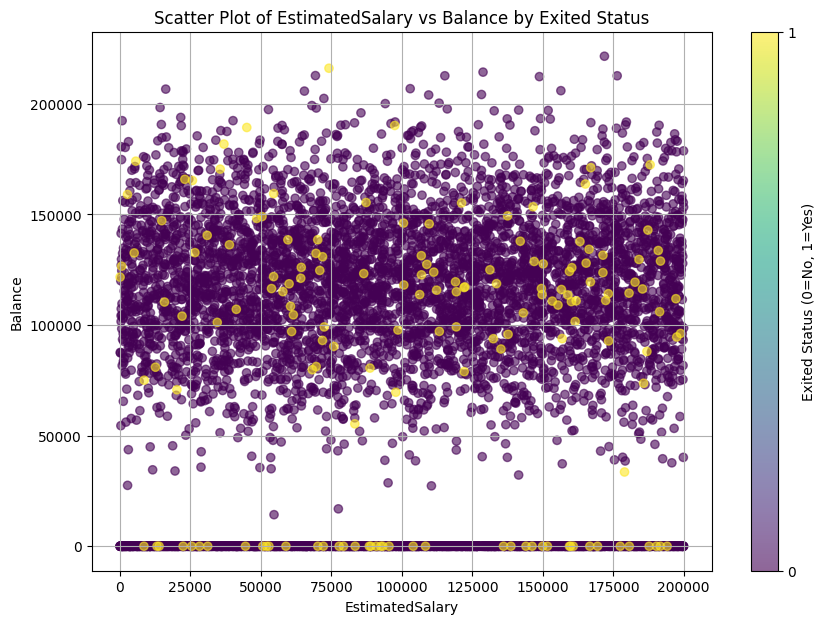

In [11]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X['EstimatedSalary'], X['Balance'], c=y, cmap='viridis', alpha=0.6)
plt.xlabel('EstimatedSalary')
plt.ylabel('Balance')
plt.title('Scatter Plot of EstimatedSalary vs Balance by Exited Status')
plt.colorbar(scatter, ticks=[0, 1], label='Exited Status (0=No, 1=Yes)')
plt.grid(True)
plt.show()

d) Lengkapilah fungsi di bawah ini untuk melakukan oversampling pada setiap fold ketika melakukan cross validation pada suatu model menggunakan StratifiedKFold dengan k=5, shuffle=True, dan random_state=42. Tampilkan juga rata-rata skor accuracy, f1 macro, precision macro, dan recall macro.

Jalankan fungsi tersebut dengan menggunakan:
- DecisionTreeClassifier, dengan random_state=42
- Teknik oversampling RandomOversampler, dengan random_state=42
- X dan y yang didefinisikan pada soal (1a)

*(Pastikan validation test dataset tidak terganggu oleh penambahan data - data sintetis.)*

In [18]:
def train_and_evaluate_with_oversampling(model, X, y, resample_method):
    if isinstance(X, pd.DataFrame):
        X = X.values

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    accuracy_scores = []
    f1_scores = []
    precision_scores = []
    recall_scores = []

    for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
        X_train = X[train_index]
        y_train = y[train_index]
        X_test = X[test_index]
        y_test = y[test_index]


        X_train_sampled, y_train_sampled = resample_method.fit_resample(X_train, y_train)

        model_clone = clone(model)

        model_clone.fit(X_train_sampled, y_train_sampled)

        y_pred = model_clone.predict(X_test)

        accuracy = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred, average="macro")
        precision = precision_score(y_test, y_pred, average="macro")
        recall = recall_score(y_test, y_pred, average="macro")

        accuracy_scores.append(accuracy)
        f1_scores.append(f1)
        precision_scores.append(precision)
        recall_scores.append(recall)


    print("Mean scores across all folds:")
    print(f'Mean Accuracy: {np.mean(accuracy_scores):.4f}')
    print(f'Mean F1-score (macro): {np.mean(f1_scores):.4f}')
    print(f'Mean Precision (macro): {np.mean(precision_scores):.4f}')
    print(f'Mean Recall (macro): {np.mean(recall_scores):.4f}')

In [19]:
model = DecisionTreeClassifier(random_state=42)
resampler = RandomOverSampler(random_state=42)

train_and_evaluate_with_oversampling(model, X, y, resampler)

Mean scores across all folds:
Mean Accuracy: 0.9636
Mean F1-score (macro): 0.4976
Mean Precision (macro): 0.4976
Mean Recall (macro): 0.4977


e) Jalankan kode di bawah ini. Apakah terdapat perbedaan skor dengan yang ada pada soal (1d)? Jika berbeda, mengapa hal tersebut bisa terjadi, dan approach manakah yang lebih tepat untuk dilakukan (approach (1d) atau (1e))?

In [16]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
X_oversampled, y_oversampled = RandomOverSampler(random_state=42).fit_resample(X, y)

scoring = ['accuracy','f1_macro', 'precision_macro', 'recall_macro']
for i in range(len(scoring)):
  score = cross_val_score(DecisionTreeClassifier(random_state=42), X_oversampled, y_oversampled, scoring=scoring[i], cv=cv, n_jobs=-1)
  print(f"{scoring[i]} score: {np.mean(score):.4f}")

accuracy score: 0.9889
f1_macro score: 0.9889
precision_macro score: 0.9892
recall_macro score: 0.9889


f) Mengapa StratifiedKFold umumnya lebih sering digunakan dalam kasus Imbalanced dataset dibandingkan KFold biasa? Jelaskan serta berikan sumber referensi anda.

StratifiedKFold umumnya lebih disukai daripada KFold biasa ketika berurusan dengan dataset yang tidak seimbang karena cara pembuatan lipatannya:
* Dalam KFold biasa, dataset hanya dibagi menjadi k lipatan tanpa mempertimbangkan distribusi kelas. Untuk dataset yang tidak seimbang, ini dapat menyebabkan beberapa lipatan memiliki sangat sedikit atau bahkan nol instance dari kelas minoritas. Jika set pelatihan suatu lipatan tidak memiliki kelas minoritas, model tidak akan belajar untuk memprediksinya. Jika set pengujian suatu lipatan tidak memiliki kelas minoritas, metrik evaluasi untuk kelas tersebut akan tidak terdefinisi atau menyesatkan.
* StratifiedKFold memastikan bahwa setiap lipatan mempertahankan proporsi observasi yang sama untuk setiap kelas target seperti dataset asli. Misalnya, jika dataset Anda memiliki 90% kelas A dan 10% kelas B, maka setiap fold yang dibuat oleh StratifiedKFold juga akan berisi sekitar 90% kelas A dan 10% kelas B.




## 2. Oversampling

a) Terapkan metode oversampling yang paling sesuai menurut anda dan bisa diterapkan dengan dataset soal (1a). Visualisasikan scatter plot hasil resampling datasetnya

Original dataset shape: Counter({0: 7962, 1: 159})
Resampled dataset shape (SMOTE): Counter({0: 7962, 1: 7962})


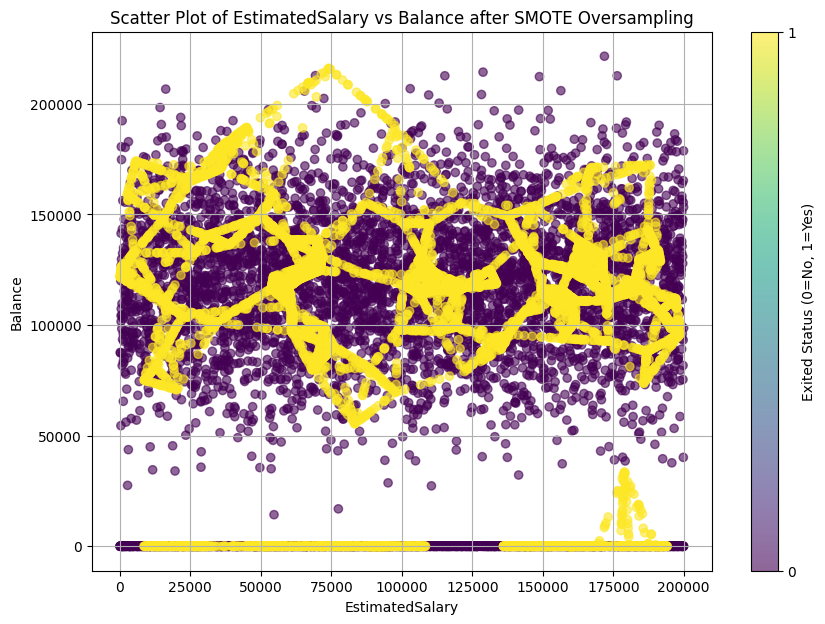

In [20]:
from imblearn.over_sampling import SMOTE

smote_resampler = SMOTE(random_state=42)
X_smote, y_smote = smote_resampler.fit_resample(X, y)

print(f'Original dataset shape: {Counter(y)}')
print(f'Resampled dataset shape (SMOTE): {Counter(y_smote)}')

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_smote['EstimatedSalary'], X_smote['Balance'], c=y_smote, cmap='viridis', alpha=0.6)
plt.xlabel('EstimatedSalary')
plt.ylabel('Balance')
plt.title('Scatter Plot of EstimatedSalary vs Balance after SMOTE Oversampling')
plt.colorbar(scatter, ticks=[0, 1], label='Exited Status (0=No, 1=Yes)')
plt.grid(True)
plt.show()

b) Terapkan metode oversampling yang lain yang berbeda dengan metode pada soal (2a). Visualisasikan scatter plot hasil resampling datasetnya

In [23]:
from imblearn.over_sampling import ADASYN

adasyn_resampler = ADASYN(random_state=42)
X_adasyn, y_adasyn = adasyn_resampler.fit_resample(X, y)

print(f'Original dataset shape: {Counter(y)}')
print(f'Resampled dataset shape (ADASYN): {Counter(y_adasyn)}')

Original dataset shape: Counter({0: 7962, 1: 159})
Resampled dataset shape (ADASYN): Counter({1: 7999, 0: 7962})


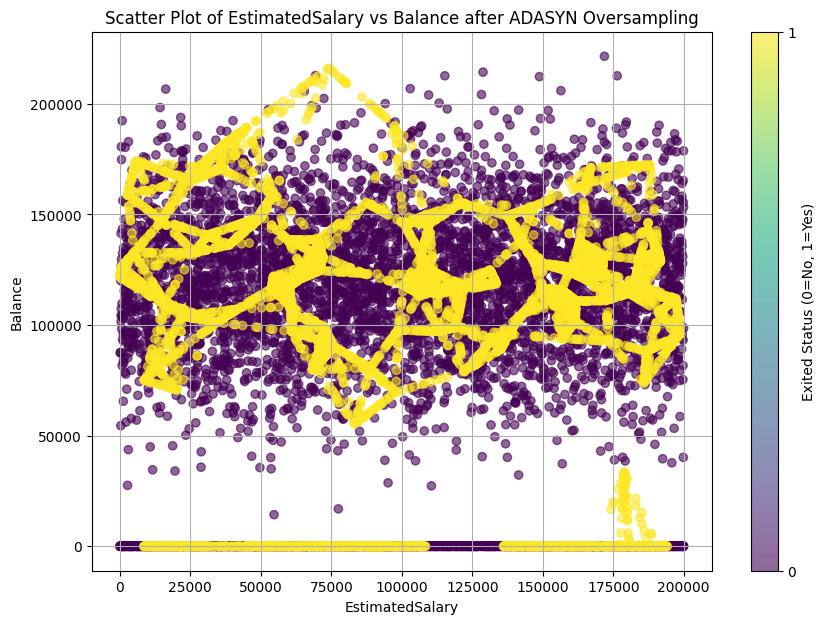

In [24]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_adasyn['EstimatedSalary'], X_adasyn['Balance'], c=y_adasyn, cmap='viridis', alpha=0.6)
plt.xlabel('EstimatedSalary')
plt.ylabel('Balance')
plt.title('Scatter Plot of EstimatedSalary vs Balance after ADASYN Oversampling')
plt.colorbar(scatter, ticks=[0, 1], label='Exited Status (0=No, 1=Yes)')
plt.grid(True)
plt.show()

c) Adakah perbedaan yang Anda temukan dari pengamatan terhadap data hasil kedua metode oversampling yang Anda pilih? Jika ada, jelaskan mengapa perbedaan tersebut bisa terjadi! Sertakan sumber referensi anda

Ya, memang ada perbedaan yang terlihat antara hasil metode oversampling SMOTE dan ADASYN, baik secara numerik maupun visual dari plot sebaran.
1. Perbedaan Numerik (dari output Counter):
Bentuk dataset asli: Counter({0: 7962, 1: 159})
Bentuk dataset yang di-resampling (SMOTE): Counter({0: 7962, 1: 7962})
Bentuk dataset yang di-resampling (ADASYN): Counter({1: 7999, 0: 7962})
Perhatikan bahwa SMOTE menyeimbangkan kelas dengan sempurna, menghasilkan jumlah sampel yang sama untuk kedua kelas. Namun, ADASYN menghasilkan sedikit lebih banyak sampel untuk kelas minoritas (7999 untuk kelas 1) daripada kelas mayoritas (7962 untuk kelas 0).

2. Perbedaan Visual (dari Plot Sebar):
SMOTE (Sel b09a98fe): Anda akan mengamati bahwa SMOTE menghasilkan sampel sintetis di sepanjang segmen garis yang menghubungkan instance kelas minoritas yang ada. Ini cenderung menciptakan titik data sintetis di dalam klaster kelas minoritas yang ada, secara efektif memperluas kepadatannya. Titik-titik sintetis dihasilkan dengan cara yang lebih seragam di antara sampel minoritas yang ada. ADASYN (Sel x-zk5UFN84Iz): ADASYN juga menghasilkan sampel sintetis, tetapi cenderung berfokus pada pembuatan sampel di wilayah di mana instance kelas minoritas lebih sulit dipelajari, yaitu, yang dekat dengan batas keputusan atau dikelilingi oleh instance kelas mayoritas. Ini dapat menghasilkan sampel sintetis yang sedikit di luar selubung cembung asli kelas minoritas, atau di area yang tampak kurang padat dengan sampel minoritas asli tetapi menantang bagi pengklasifikasi. Distribusi titik yang dihasilkan ADASYN mungkin tampak lebih tersebar, terutama ke arah batas dengan kelas mayoritas.

d) Lakukan cross validation menggunakan StratifiedKFold dengan k=5 pada 2 buah model Decision Tree yang berbeda dengan ketentuan berikut:
- Model pertama menggunakan metode oversampling yang dipakai pada (2a)
- Model kedua menggunakan metode oversampling yang dipakai pada (2b)
- Metrik utama yang digunakan adalah f1 macro.
- Oversampling dilakukan pada setiap fold cross validation

Petunjuk: Anda bisa menggunakan cara 1d untuk menjawab soal ini.

*(Pastikan validation test dataset tidak terganggu oleh penambahan data - data sintetis.)*

In [27]:
dt_model_smote = DecisionTreeClassifier(random_state=42)
smote_resampler = SMOTE(random_state=42)

print("Decision Tree with SMOTE Oversampling:")
train_and_evaluate_with_oversampling(dt_model_smote, X, y, smote_resampler)

Decision Tree with SMOTE Oversampling:
Mean scores across all folds:
Mean Accuracy: 0.7195
Mean F1-score (macro): 0.4388
Mean Precision (macro): 0.5020
Mean Recall (macro): 0.5208


In [28]:
dt_model_adasyn = DecisionTreeClassifier(random_state=42)
adasyn_resampler = ADASYN(random_state=42)

print("\nDecision Tree with ADASYN Oversampling:")
train_and_evaluate_with_oversampling(dt_model_adasyn, X, y, adasyn_resampler)


Decision Tree with ADASYN Oversampling:
Mean scores across all folds:
Mean Accuracy: 0.7094
Mean F1-score (macro): 0.4305
Mean Precision (macro): 0.4983
Mean Recall (macro): 0.4818


e) Metode manakah yang memberikan skor F1 makro tertinggi? Jelaskan mengapa hal tersebut bisa terjadi.

Berdasarkan hasil validasi silang:
* SMOTE Oversampling: Rata-rata skor F1 (makro): 0,4388
* ADASYN Oversampling: Rata-rata skor F1 (makro): 0,4305
* SMOTE memberikan skor makro F1 yang sedikit lebih tinggi.

Perbedaan ini dapat dikaitkan dengan cara masing-masing algoritma menghasilkan sampel sintetis dan bagaimana model Pohon Keputusan belajar darinya SMOTE (Synthetic Minority Over-sampling Technique): SMOTE menghasilkan sampel baru dengan melakukan interpolasi antara instance kelas minoritas dan tetangga kelas minoritas yang sudah ada. Ini umumnya menciptakan titik sintetis di dalam klaster kelas minoritas yang sudah ada.

## 3. Undersampling

a) Terapkan metode undersampling yang paling sesuai menurut anda dan bisa diterapkan dengan dataset soal (1a). Visualisasikan scatter plot hasil resampling datasetnya

Original dataset shape: Counter({0: 7962, 1: 159})
Resampled dataset shape (RandomUnderSampler): Counter({0: 159, 1: 159})


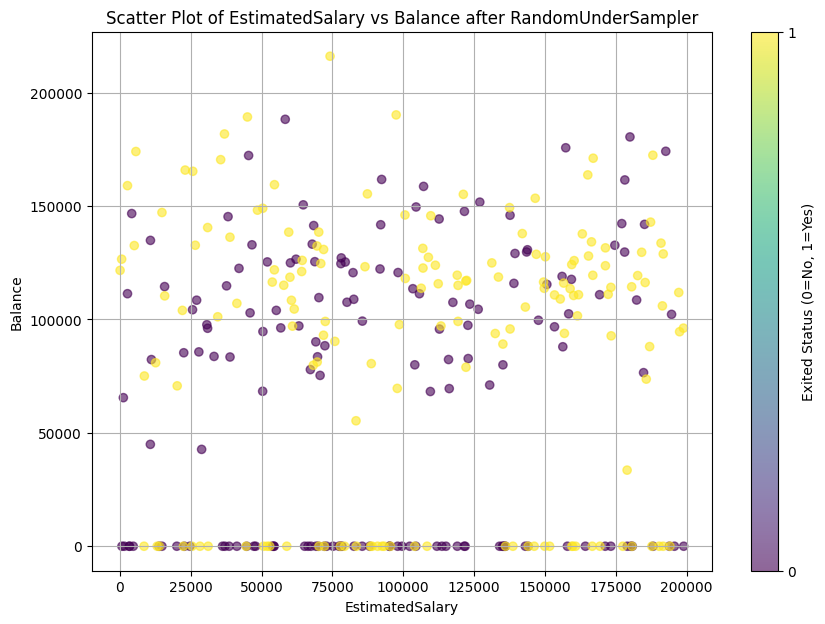

In [29]:
from imblearn.under_sampling import RandomUnderSampler

rus_resampler = RandomUnderSampler(random_state=42)
X_rus, y_rus = rus_resampler.fit_resample(X, y)

print(f'Original dataset shape: {Counter(y)}')
print(f'Resampled dataset shape (RandomUnderSampler): {Counter(y_rus)}')

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_rus['EstimatedSalary'], X_rus['Balance'], c=y_rus, cmap='viridis', alpha=0.6)
plt.xlabel('EstimatedSalary')
plt.ylabel('Balance')
plt.title('Scatter Plot of EstimatedSalary vs Balance after RandomUnderSampler')
plt.colorbar(scatter, ticks=[0, 1], label='Exited Status (0=No, 1=Yes)')
plt.grid(True)
plt.show()

b) Terapkan metode undersampling lain yang berbeda dengan metode pada soal (3a). Visualisasikan scatter plot hasil resampling datasetnya

Original dataset shape: Counter({0: 7962, 1: 159})
Resampled dataset shape (TomekLinks): Counter({0: 7866, 1: 159})


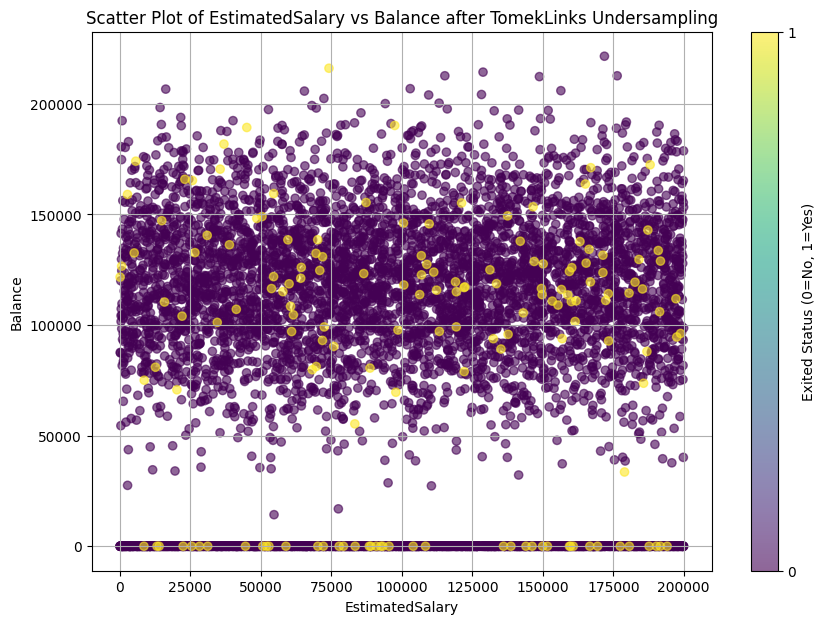

In [31]:
from imblearn.under_sampling import TomekLinks

tomek_resampler = TomekLinks(sampling_strategy='majority')
X_tomek, y_tomek = tomek_resampler.fit_resample(X, y)

print(f'Original dataset shape: {Counter(y)}')
print(f'Resampled dataset shape (TomekLinks): {Counter(y_tomek)}')

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_tomek['EstimatedSalary'], X_tomek['Balance'], c=y_tomek, cmap='viridis', alpha=0.6)
plt.xlabel('EstimatedSalary')
plt.ylabel('Balance')
plt.title('Scatter Plot of EstimatedSalary vs Balance after TomekLinks Undersampling')
plt.colorbar(scatter, ticks=[0, 1], label='Exited Status (0=No, 1=Yes)')
plt.grid(True)
plt.show()

c) Berdasarkan visualisasi scatter plot kedua dataset hasil resampling pada soal (3a) dan (3b) yang Anda pilih, apa perbedaan yang terlihat? Jelaskan juga mengapa perbedaan tersebut bisa terjadi! Jangan lupa sertakan sumber referensi anda

Perbedaan antara RandomUnderSampler (3a) dan TomekLinks (3b):

1.  Perbedaan Numerik (Distribusi Kelas):
    * RandomUnderSampler (Output Cell `d5c82b7f`): Menghasilkan `Counter({0: 159, 1: 159})`. Ini berarti `RandomUnderSampler` secara acak menghapus sejumlah besar sampel dari kelas mayoritas (0) sehingga jumlahnya sama dengan kelas minoritas (1). Terjadi pengurangan drastis pada jumlah sampel kelas mayoritas.
    * TomekLinks (Output Cell `b9c34a75`): Menghasilkan `Counter({0: 7866, 1: 159})`. `TomekLinks` hanya menghapus sejumlah kecil sampel dari kelas mayoritas (0), yaitu sampel yang membentuk 'Tomek Link' dengan sampel kelas minoritas. Jumlah sampel kelas minoritas (1) tetap sama.

2.  Perbedaan Visual (Scatter Plot):
    * RandomUnderSampler (Plot Cell `d5c82b7f`): Plot ini akan menunjukkan sangat sedikit titik data untuk kedua kelas, karena sebagian besar sampel kelas mayoritas telah dihapus secara acak. Distrubusi kedua kelas akan terlihat jauh lebih jarang, dan pola asli data mayoritas mungkin menjadi kurang jelas karena banyak informasi telah hilang.
    * TomekLinks (Plot Cell `b9c34a75`): Plot ini akan terlihat sangat mirip dengan plot dataset asli, terutama karena hanya sedikit sampel kelas mayoritas yang dihapus. Perubahan yang terjadi sangat halus dan mungkin tidak terlihat jelas secara visual tanpa membandingkan titik-titik secara individual. Fokusnya adalah pada 'batas' antar kelas, bukan pada pengurangan drastis jumlah sampel mayoritas.

d) Lakukan cross validation menggunakan StratifiedKFold dengan k=5 pada 2 buah model Decision Tree yang berbeda dengan ketentuan berikut:
- Model pertama menerima dataset pada soal (3a)
- Model kedua menerima dataset pada soal (3b)
- Metrik utama yang digunakan adalah f1 macro.

In [32]:
dt_model_rus = DecisionTreeClassifier(random_state=42)
rus_resampler = RandomUnderSampler(random_state=42)

print("Decision Tree with RandomUnderSampler:")
train_and_evaluate_with_oversampling(dt_model_rus, X, y, rus_resampler)

Decision Tree with RandomUnderSampler:
Mean scores across all folds:
Mean Accuracy: 0.4987
Mean F1-score (macro): 0.3500
Mean Precision (macro): 0.5008
Mean Recall (macro): 0.5103


In [33]:
dt_model_tomek = DecisionTreeClassifier(random_state=42)
tomek_resampler = TomekLinks(sampling_strategy='majority')

print("\nDecision Tree with TomekLinks Undersampling:")
train_and_evaluate_with_oversampling(dt_model_tomek, X, y, tomek_resampler)


Decision Tree with TomekLinks Undersampling:
Mean scores across all folds:
Mean Accuracy: 0.9591
Mean F1-score (macro): 0.4956
Mean Precision (macro): 0.4960
Mean Recall (macro): 0.4953


e) Metode manakah yang memberikan skor F1 makro tertinggi? Jelaskan mengapa hal tersebut bisa terjadi.

* Decision Tree dengan RandomUnderSampler: Skor F1 rata-rata (makro): 0,3500
* Decision Tree dengan TomekLinks Undersampling: Skor F1 rata-rata (makro): 0,4956

Bisa dilihat, TomekLinks Undersampling menghasilkan skor makro F1 yang jauh lebih tinggi.
RandomUnderSampler, dengan penghapusan data kelas mayoritas secara signifikan, berisiko kehilangan informasi penting, yang menyebabkan model menjadi kurang efektif. TomekLinks, di sisi lain, melakukan penghapusan strategis untuk meningkatkan keterpisahan kelas sambil mempertahankan lebih banyak data yang relevan, sehingga menghasilkan kinerja makro F1 yang superior dalam skenario ini.

## 4. Cost-Sensitive Learning

a) Buatlah beberapa model decision tree dengan random_state=42 yang menerima dataset soal (1a) dan dengan weight yang berbeda, yaiu:
- tanpa weights
- weights = {0: 1, 1: 2}
- weights = {0: 1, 1: 99}

Lakukan train_test_split dengan ketentuan berikut:
- menggunakan X dan y dari soal (1a)
- stratify=y
- random_state=42
- test_size=0.2

Kemudian, lakukan fit predict pada model dengan weights yang berbeda, kemudian tampilkan skor f1 macro dan juga confusion matrix untuk masing-masing model DT dengan weights yang berbeda tersebut. Berikan label pada Confusion matrix nya


--- Model Tanpa Weights ---
F1 Macro Score: 0.4906


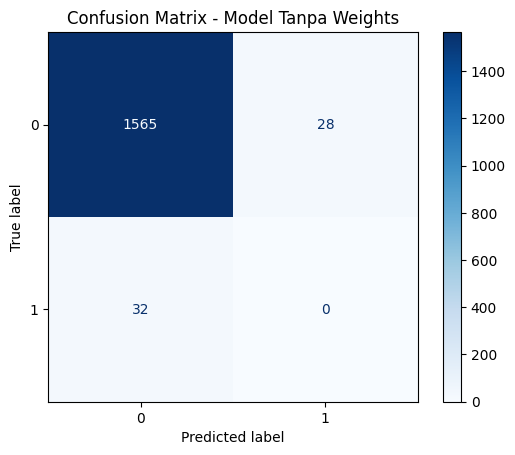


--- Model dengan Weights {0:1, 1:2} ---
F1 Macro Score: 0.4901


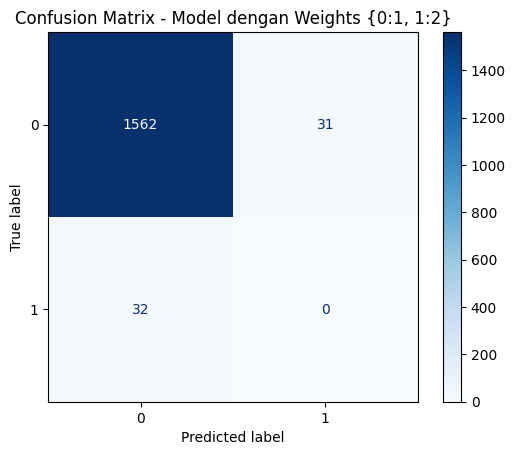


--- Model dengan Weights {0:1, 1:99} ---
F1 Macro Score: 0.4895


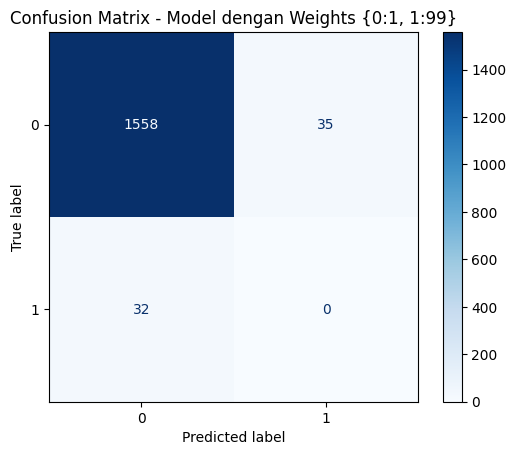

In [35]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

def evaluate_dt_with_weights(X_train, X_test, y_train, y_test, weights, model_name):
    dt_model = DecisionTreeClassifier(random_state=42, class_weight=weights)
    dt_model.fit(X_train, y_train)
    y_pred = dt_model.predict(X_test)

    print(f"\n--- {model_name} ---")
    print(f"F1 Macro Score: {f1_score(y_test, y_pred, average='macro'):.4f}")

    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])
    disp.plot(cmap=plt.cm.Blues)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.show()

# Model 1: Tanpa weights
evaluate_dt_with_weights(X_train, X_test, y_train, y_test, None, "Model Tanpa Weights")

# Model 2: weights = {0: 1, 1: 2}
evaluate_dt_with_weights(X_train, X_test, y_train, y_test, {0: 1, 1: 2}, "Model dengan Weights {0:1, 1:2}")

# Model 3: weights = {0: 1, 1: 99}
evaluate_dt_with_weights(X_train, X_test, y_train, y_test, {0: 1, 1: 99}, "Model dengan Weights {0:1, 1:99}")

b) Berdasarkan jawaban pada soal (4a), Apakah terdapat perbedaan pada confusion matrix dan score f1 macro masing-masing weights? Jelaskan.

* Skor makro F1 untuk ketiga model (no weights, {0:1, 1:2}, {0:1, 1:99}) sangat mirip, berkisar sempit dari 0,4906 hingga 0,4895. Tidak ada peningkatan signifikan pada skor makro F1, dan bahkan menunjukkan sedikit penurunan saat bobot kelas minoritas meningkat.
* Tanpa weights (atau weights kelas minoritas rendah): Model biasanya memprioritaskan kelas mayoritas. Ini menghasilkan True Negatif yang tinggi (mengidentifikasi kelas mayoritas dengan benar) tetapi seringkali Negatif Palsu yang tinggi (gagal mengidentifikasi banyak contoh kelas minoritas) dan True Positif  yang rendah untuk kelas minoritas.


## 5. Neural Network dan Pipeline

a) Buatlah sebuah model MLPClassifier dengan kriteria sebagai berikut:
- Memiliki 3 hidden layer dengan masing - masing layer terdiri dari 50, 40, dan 20 berturut - turut
- Menggunakan random_state=42
- Abaikan hyperparameter lain

In [41]:
mlp_model_1 = MLPClassifier(hidden_layer_sizes=(50, 40, 20), random_state=42)
print("MLPClassifier Model 1 created successfully.")

MLPClassifier Model 1 created successfully.


b) Buatlah sebuah model MLPClassifier dengan kriteria sebagai berikut:
- Memiliki 2 hidden layer dengan masing - masing layer terdiri dari 100 dan 80 berturut - turut
- Menggunakan random_state=42
- Abaikan hyperparameter lain

In [42]:
mlp_model_2 = MLPClassifier(hidden_layer_sizes=(100, 80), random_state=42)
print("MLPClassifier Model 2 created successfully.")

MLPClassifier Model 2 created successfully.


c) Lakukan cross validation menggunakan **Stratified K-fold** dengan k=5 dan random_state=42 terhadap kedua model MLP pada soal (5a) dan (5b) memakai X dan y yang didefinisikan pada soal (1a). Metrik evaluasi yang digunakan adalah f1 macro dan f1 micro. Tampilkan hasil rata-rata dari metriknya

In [43]:
def evaluate_mlp_models(model, X, y):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

    f1_macro_scores = []
    f1_micro_scores = []

    for fold, (train_index, test_index) in enumerate(skf.split(X, y), 1):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model_clone = clone(model)
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_test)

        f1_macro_scores.append(f1_score(y_test, y_pred, average='macro'))
        f1_micro_scores.append(f1_score(y_test, y_pred, average='micro'))

    print(f'Mean F1 Macro Score: {np.mean(f1_macro_scores):.4f}')
    print(f'Mean F1 Micro Score: {np.mean(f1_micro_scores):.4f}')

print("Evaluating MLPClassifier Model 1:")
evaluate_mlp_models(mlp_model_1, X, y)

print("\nEvaluating MLPClassifier Model 2:")
evaluate_mlp_models(mlp_model_2, X, y)

Evaluating MLPClassifier Model 1:
Mean F1 Macro Score: 0.4943
Mean F1 Micro Score: 0.9775

Evaluating MLPClassifier Model 2:
Mean F1 Macro Score: 0.4915
Mean F1 Micro Score: 0.9628


d) Apakah terdapat perbedaan skor metrik makro evaluasi model pada soal (5c)? Jelaskan keterkaitan perbedaan skor dengan perbedaan hyperparameter kedua model!

Berdasarkan hasil evaluasi:
*   **MLPClassifier Model 1 (hidden_layer_sizes=(50, 40, 20))**: Mean F1 Macro Score: 0.4943, Mean F1 Micro Score: 0.9775
*   **MLPClassifier Model 2 (hidden_layer_sizes=(100, 80))**: Mean F1 Macro Score: 0.4915, Mean F1 Micro Score: 0.9628

**Perbedaan Skor Metrik Makro:**
Terdapat perbedaan tipis pada skor F1 Makro. MLPClassifier Model 1 memiliki skor F1 Makro yang sedikit lebih tinggi (0.4943) dibandingkan dengan MLPClassifier Model 2 (0.4915). Sementara itu, MLPClassifier Model 1 juga memiliki F1 Micro Score yang lebih tinggi.

**Keterkaitan Perbedaan Skor dengan Perbedaan Hyperparameter:**
Perbedaan utama antara kedua model ini adalah konfigurasi `hidden_layer_sizes`:

*   **MLPClassifier Model 1** menggunakan 3 hidden layer dengan jumlah neuron yang menurun (50, 40, 20). Konfigurasi ini cenderung menciptakan model yang lebih "dalam" (deep network) dengan lebih banyak lapisan tetapi dengan ukuran lapisan yang semakin kecil. Hal ini memungkinkan model untuk mempelajari representasi fitur yang lebih hierarkis dan kompleks dari data. Dalam beberapa kasus, model yang lebih dalam dapat menangkap pola yang lebih halus, terutama jika data memiliki struktur yang kompleks atau tidak linear.

*   **MLPClassifier Model 2** menggunakan 2 hidden layer dengan jumlah neuron yang lebih besar (100, 80). Konfigurasi ini menciptakan model yang lebih "lebar" (wider network) dibandingkan Model 1, namun dengan lapisan yang lebih sedikit. Model yang lebih lebar per layer dapat memiliki kapasitas untuk menangkap lebih banyak variasi dalam satu tingkat representasi, tetapi mungkin kurang efektif dalam mempelajari hirarki fitur dibandingkan model yang lebih dalam dengan jumlah parameter total yang setara atau lebih banyak.

Dalam kasus ini, **Model 1 dengan arsitektur 3 layer yang lebih dalam menunjukkan kinerja F1 Macro yang sedikit lebih baik**. Ini mengindikasikan bahwa untuk dataset `X` dan `y` yang digunakan, kemampuan Model 1 untuk belajar representasi hierarkis melalui lapisan yang lebih dalam mungkin lebih efektif dalam menyeimbangkan recall dan precision untuk kedua kelas, terutama kelas minoritas yang imbalance, yang tercermin dalam skor F1 Makro. Meskipun demikian, perlu dicatat bahwa perbedaan ini relatif kecil, dan performa optimal juga bisa sangat tergantung pada hyperparameter lain (seperti learning rate, fungsi aktivasi, regularisasi) dan karakteristik spesifik dari dataset.

e) Dengan menggunakan Pipeline, lakukan cross validation menggunakan **Stratified K-fold** dengan k=5 dan random_state=42 pada sebuah pipeline yang berisi steps yaitu oversampling menggunakan SMOTE dengan random_state=42 dan menggunakan model MLP yang memiliki performa lebih bagus dari soal (5a) dan (5b). Gunakan X dan y yang didefinisikan pada soal (1a) untuk melakukan cross validation. Metrik evaluasi yang digunakan adalah f1 macro dan f1 micro. Tampilkan hasil rata-rata dari metriknya

In [44]:
pipeline_smote_mlp = Pipeline([
    ('oversampler', SMOTE(random_state=42)),
    ('mlp', mlp_model_1) # Using mlp_model_1 as it had slightly better F1 macro
])

skf_pipeline = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_macro_scores_smote_mlp = []
f1_micro_scores_smote_mlp = []

print("Evaluating Pipeline with SMOTE and MLP Model 1:")
for fold, (train_index, test_index) in enumerate(skf_pipeline.split(X, y), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Clone the pipeline to ensure a fresh start for each fold
    pipeline_clone = clone(pipeline_smote_mlp)

    pipeline_clone.fit(X_train, y_train)
    y_pred = pipeline_clone.predict(X_test)

    f1_macro_scores_smote_mlp.append(f1_score(y_test, y_pred, average='macro'))
    f1_micro_scores_smote_mlp.append(f1_score(y_test, y_pred, average='micro'))

print(f'Mean F1 Macro Score (SMOTE + MLP Model 1): {np.mean(f1_macro_scores_smote_mlp):.4f}')
print(f'Mean F1 Micro Score (SMOTE + MLP Model 1): {np.mean(f1_micro_scores_smote_mlp):.4f}')

Evaluating Pipeline with SMOTE and MLP Model 1:
Mean F1 Macro Score (SMOTE + MLP Model 1): 0.1841
Mean F1 Micro Score (SMOTE + MLP Model 1): 0.2513


f) Dengan menggunakan Pipeline, lakukan cross validation menggunakan **Stratified K-fold** dengan k=5 dan random_state=42 pada sebuah pipeline yang berisi steps yaitu undersampling menggunakan RandomUnderSampler dengan random_state=42 dan menggunakan model MLP yang memiliki performa lebih bagus dari soal (5a) dan (5b). Gunakan X dan y yang didefinisikan pada soal (1a) untuk melakukan cross validation. Metrik evaluasi yang digunakan adalah f1 macro dan f1 micro. Tampilkan hasil rata-rata dari metriknya

In [45]:
pipeline_rus_mlp = Pipeline([
    ('undersampler', RandomUnderSampler(random_state=42)),
    ('mlp', mlp_model_1) # Using mlp_model_1 as it had slightly better F1 macro
])

skf_pipeline_rus = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

f1_macro_scores_rus_mlp = []
f1_micro_scores_rus_mlp = []

print("Evaluating Pipeline with RandomUnderSampler and MLP Model 1:")
for fold, (train_index, test_index) in enumerate(skf_pipeline_rus.split(X, y), 1):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    y_train, y_test = y.iloc[train_index], y.iloc[test_index]

    # Clone the pipeline to ensure a fresh start for each fold
    pipeline_clone_rus = clone(pipeline_rus_mlp)

    pipeline_clone_rus.fit(X_train, y_train)
    y_pred = pipeline_clone_rus.predict(X_test)

    f1_macro_scores_rus_mlp.append(f1_score(y_test, y_pred, average='macro'))
    f1_micro_scores_rus_mlp.append(f1_score(y_test, y_pred, average='micro'))

print(f'Mean F1 Macro Score (RandomUnderSampler + MLP Model 1): {np.mean(f1_macro_scores_rus_mlp):.4f}')
print(f'Mean F1 Micro Score (RandomUnderSampler + MLP Model 1): {np.mean(f1_micro_scores_rus_mlp):.4f}')

Evaluating Pipeline with RandomUnderSampler and MLP Model 1:
Mean F1 Macro Score (RandomUnderSampler + MLP Model 1): 0.2971
Mean F1 Micro Score (RandomUnderSampler + MLP Model 1): 0.4364


## 6. Soal Teoritis Neural Network

a) Apabila dalam binary classification dibutuhkan 1 neuron dalam output layer, berapa neuron yang dibutuhkan dalam output layer untuk multiclass classification? Berikan contoh dan sertakan sumber referensi yang kalian gunakan.

Untuk **binary classification**, biasanya **1 neuron** dibutuhkan di lapisan output, seringkali dengan fungsi aktivasi sigmoid, di mana output merepresentasikan probabilitas milik kelas positif (misalnya, probabilitas 1 vs 0).

Untuk **multiclass classification**, Anda biasanya membutuhkan **'N' neuron** di lapisan output, di mana 'N' adalah jumlah total kelas. Setiap neuron sesuai dengan salah satu kelas.

**Penjelasan dan Fungsi Aktivasi:**

*   **One-hot Encoding:** Dalam klasifikasi multiclass, variabel target `y` biasanya direpresentasikan menggunakan one-hot encoding. Misalnya, jika ada 3 kelas (Kucing, Anjing, Burung):
    *   Kucing: `[1, 0, 0]`
    *   Anjing: `[0, 1, 0]`
    *   Burung: `[0, 0, 1]`

*   **Softmax Activation:** Lapisan output biasanya menggunakan **fungsi aktivasi softmax**. Softmax mengambil output mentah (logits) dari 'N' neuron dan mengubahnya menjadi distribusi probabilitas di atas 'N' kelas. Jumlah probabilitas ini di semua neuron output akan sama dengan 1. Prediksi model untuk input tertentu akan menjadi kelas yang sesuai dengan neuron dengan output probabilitas tertinggi.



b) Diketahui terdapat hyperparameter berikut pada MLPClassifier:
- hidden_layer_sizes
- learning_rate_init

Untuk masing-masing hyperparameter tersebut, jelaskan apa yang akan terjadi jika kita menetapkan value yang berbeda (misalnya menjelaskan perbedaan hidden_layer_size=(50,50) vs (100,50), dsb.). Asumsikan hyperparameter learning_rate yang dipakai adalah constant.

Sertakan sumber referensi anda.

Penjelasan Hyperparameter pada `MLPClassifier`:

1. `hidden_layer_sizes`

Parameter ini mendefinisikan arsitektur lapisan tersembunyi (hidden layers) pada jaringan saraf. Ini adalah tuple, di mana setiap elemen dalam tuple merepresentasikan jumlah neuron dalam satu lapisan tersembunyi. Misalnya, `(50, 40, 20)` berarti ada tiga lapisan tersembunyi; lapisan pertama memiliki 50 neuron, lapisan kedua memiliki 40 neuron, dan lapisan ketiga memiliki 20 neuron.

Dampak Perbedaan Nilai:

*   Jumlah Lapisan (Kedalaman Jaringan):
    * Jaringan yang Lebih Dalam (misal: `(50, 40, 20)` vs `(100, 80)`): Jaringan dengan lebih banyak lapisan tersembunyi (lebih dalam) cenderung dapat mempelajari fitur yang lebih hierarkis dan kompleks dari data. Setiap lapisan dapat menangkap abstraksi yang berbeda. Ini sangat berguna untuk data dengan pola non-linear atau kompleks. Namun, jaringan yang terlalu dalam bisa lebih sulit dilatih (misalnya, masalah vanishing/exploding gradients) dan membutuhkan lebih banyak data serta waktu komputasi.

*  Jumlah Neuron per Lapisan (Lebar Jaringan):
    * Jaringan yang Lebih Lebar (misal: `(100, 80)` vs `(50, 50)`): Jaringan dengan lebih banyak neuron di setiap lapisan (lebih lebar) memiliki kapasitas yang lebih besar untuk mempelajari pola. Ini berarti model dapat menyimpan lebih banyak "pengetahuan" pada satu tingkat abstraksi. Namun, jaringan yang terlalu lebar dapat menyebabkan *overfitting* (model terlalu mempelajari noise dalam data pelatihan), dan juga meningkatkan waktu serta memori komputasi.

2. `learning_rate_init`

Parameter ini menentukan ukuran langkah awal yang diambil oleh algoritma optimisasi (misalnya, *gradient descent* atau variannya) saat memperbarui bobot model selama pelatihan. Ini adalah kecepatan di mana model "belajar" atau menyesuaikan bobotnya berdasarkan kesalahan prediksi.

Dampak Perbedaan Nilai (dengan asumsi learning rate konstan):

* Nilai `learning_rate_init` yang Sangat Kecil (misal: 0.0001):
    * Efek: Model akan membuat penyesuaian bobot yang sangat kecil di setiap iterasi. Pelatihan akan sangat lambat, dan mungkin membutuhkan banyak epoch untuk mencapai konvergensi (titik di mana loss tidak lagi berkurang secara signifikan). Ada risiko terjebak dalam *local minima* yang dangkal atau membutuhkan waktu yang sangat lama untuk menemukan minimum global.

* Nilai `learning_rate_init` yang Sangat Besar (misal: 1.0):
    * Model akan membuat penyesuaian bobot yang besar di setiap iterasi. Ini bisa menyebabkan bobot model berosilasi secara liar di sekitar minimum optimal, atau bahkan *diverge* (loss justru meningkat, bukan menurun), sehingga model tidak pernah mencapai konvergensi atau mencapai kinerja yang buruk.
    * Analogi: Melompat terlalu jauh saat mencari dasar lembah. Anda mungkin melompati dasar atau bahkan keluar dari lembah sama sekali.

* Nilai `learning_rate_init` yang Optimal:
    * Efek: Memungkinkan model untuk belajar secara efisien, menyeimbangkan kecepatan konvergensi dengan stabilitas. Model dapat mencapai minimum global atau area yang mendekatinya dengan cepat tanpa divergensi atau osilasi yang signifikan.